## **1. Importing Libraries**

In [ ]:

import pandas as pd                        
import numpy as np                         

#Visualization Libraries
import matplotlib.pyplot as plt            
import seaborn as sns                      

#Statistical Libraries
from scipy.stats import zscore            
from scipy.stats import chi2_contingency  

## **2. Load Dataset**

In [2]:
#loading the dataset, reading the dataset into a pandas dataframe and displaying the first 5 rows of the dataset by using the head() function.
df = pd.read_csv("Manchester_house_Dataset[3678].csv")

df.head()


,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area
0,0,7129300520,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340
1,1,6414100192,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690
2,2,5631500400,180000,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720
3,3,2487200875,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360
4,4,1954400510,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800


In [3]:
#converting the price column from pounds to thousands of pounds by dividing the values in the price column by 1,000 and then changing the column position of the price column to be after the last column of the dataframe.

df["price_k"] = df["price"] / 1_000

#Move the price_k column near other key numerical columns for better analysis and visualization

price_k_col = df.pop("price_k")        # take the price_k column out of the dataframe

df.insert(len(df.columns), "price_k", price_k_col)  # put the price_k column back at the end of the dataframe

df.head()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area,price_k
0,0,7129300520,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340,221.9
1,1,6414100192,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690,538.0
2,2,5631500400,180000,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720,180.0
3,3,2487200875,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360,604.0
4,4,1954400510,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800,510.0


In [4]:
# Converting the area column from square feet to square meters by multiplying the (e.g., 'living_area' to 'living_area_m2', 'sqft_living' to 'sqft_living_m2', and 'sqft_total' to 'sqft_total_m2').

# Convert living area from sqft to m2 as 1 sqft = 0.092903 m2

SQFT_TO_M2 = 0.092903

df["living_area_m2"]   = df["living_area"] * SQFT_TO_M2
df["sqft_living_m2"]   = df["sqft_living"] * SQFT_TO_M2
df["sqft_total_m2"]    = df["sqft_total"] * SQFT_TO_M2
	
df.head()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area,price_k,living_area_m2,sqft_living_m2,sqft_total_m2
0,0,7129300520,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340,221.9,124.49002,109.62554,524.901950
1,1,6414100192,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690,538.0,157.00607,238.76071,672.803526
2,2,5631500400,180000,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720,180.0,252.69616,71.53531,929.030000
3,3,2487200875,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360,604.0,126.34808,182.08988,464.515000
4,4,1954400510,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800,510.0,167.22540,156.07704,750.656240


In [5]:
#Renaming the column names of the area columns to reflect the new units (e.g., 'living_area' to 'living_area_m2', 'sqft_living' to 'sqft_living_m2', and 'sqft_total' to 'sqft_total_m2').
df.rename(
    columns={
        "price_k": "price(K£)",
        "living_area_m2": "living_area(m²)",
        "sqft_living_m2": "living_area_internal(m²)",
        "sqft_total_m2": "total_area(m²)"
    },
    inplace=True
)

df.head()



,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area,price(K£),living_area(m²),living_area_internal(m²),total_area(m²)
0,0,7129300520,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340,221.9,124.49002,109.62554,524.901950
1,1,6414100192,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690,538.0,157.00607,238.76071,672.803526
2,2,5631500400,180000,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720,180.0,252.69616,71.53531,929.030000
3,3,2487200875,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360,604.0,126.34808,182.08988,464.515000
4,4,1954400510,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800,510.0,167.22540,156.07704,750.656240


In [6]:
# Check dataset shape to confirm the changes in the number of columns after adding new columns and renaming them.
print(df.shape)

(19999, 19)


In [7]:
#Checking Data Types of the columns in the dataset to ensure that the data types are appropriate for analysis and visualization.
df.dtypes

Unnamed: 0                    int64
id                            int64
price                         int64
bedrooms                    float64
bathrooms                   float64
sqft_living                   int64
sqft_total                    int64
floors                      float64
waterfront                    int64
view                          int64
condition                     int64
grade                         int64
built                         int64
renovated                     int64
living_area                   int64
price(K£)                   float64
living_area(m²)             float64
living_area_internal(m²)    float64
total_area(m²)              float64
dtype: object

In [8]:
#checking for missing values in the dataset to identify any potential issues with data quality and completeness.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                19999 non-null  int64  
 1   id                        19999 non-null  int64  
 2   price                     19999 non-null  int64  
 3   bedrooms                  19986 non-null  float64
 4   bathrooms                 19989 non-null  float64
 5   sqft_living               19999 non-null  int64  
 6   sqft_total                19999 non-null  int64  
 7   floors                    19999 non-null  float64
 8   waterfront                19999 non-null  int64  
 9   view                      19999 non-null  int64  
 10  condition                 19999 non-null  int64  
 11  grade                     19999 non-null  int64  
 12  built                     19999 non-null  int64  
 13  renovated                 19999 non-null  int64  
 14  living_area      

# **3. Feature Engineering Process**

### 3.1  Data Removal and Duplicate handling

In [9]:
#Drop Unnecessary Columns Unnamed: 0 and id as they are not relevant for analysis and visualization.
df.drop(['Unnamed: 0', 'id'], axis=1, inplace=True)

# handling duplication 
print("Duplicate Rows:", df.duplicated().sum()) # Count the number of duplicate rows in the dataset and print the count to the console


Duplicate Rows: 4


### 3.2 Column binary conversion

In [10]:
# Recode renovated, waterfront and view to binary 0/1 
binary_cols = ["renovated", "waterfront", "view"]

def to_binary(series):
    s = pd.to_numeric(series, errors="coerce")   # non-numeric value to → NaN
    s = s.fillna(0)                              # NaN value to → 0
    return (s > 0).astype(int)                   # value greater zero  >0 → 1, else 0

for c in binary_cols:     # Loop through each column name in the binary_cols list and apply the to_binary function to convert the values in those columns to binary (0 or 1) based on whether they are greater than zero or not.
    df[c] = to_binary(df[c])

print(df.head())


    price  bedrooms  bathrooms  sqft_living  sqft_total  floors  waterfront  \
0  221900       3.0       1.00         1180        5650     1.0           0   
1  538000       3.0       2.25         2570        7242     2.0           0   
2  180000       2.0       1.00          770       10000     1.0           0   
3  604000       4.0       3.00         1960        5000     1.0           0   
4  510000       3.0       2.00         1680        8080     1.0           0   

   view  condition  grade  built  renovated  living_area  price(K£)  \
0     0          3      7   1955          0         1340      221.9   
1     0          3      7   1951          1         1690      538.0   
2     0          3      6   1933          0         2720      180.0   
3     0          5      7   1965          0         1360      604.0   
4     0          3      8   1987          0         1800      510.0   

   living_area(m²)  living_area_internal(m²)  total_area(m²)  
0        124.49002                 

### 3.3 Dropping the Duplicates

In [11]:
#Drop Duplicate values in dataset we get
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (19995, 17)


In [12]:
# Check missing values before any imputation or treatment to understand the extent of missing data in the dataset and to inform the choice of appropriate methods for handling missing values.
print("Missing values before treatment:\n", df.isna().sum())

Missing values before treatment:
 price                        0
bedrooms                    13
bathrooms                   10
sqft_living                  0
sqft_total                   0
floors                       0
waterfront                   0
view                         0
condition                    0
grade                        0
built                        0
renovated                    0
living_area                  0
price(K£)                    0
living_area(m²)              0
living_area_internal(m²)     0
total_area(m²)               0
dtype: int64


In [13]:
#impute missing values in the "bedrooms", "bathrooms", and "floors" columns by converting the values in these columns to numeric format, treating any non-numeric values as missing (NaN), filling the missing values with the median of each column, and then converting the resulting values to integers.
cols = ["bedrooms", "bathrooms", "floors"]

for col in cols:
    df[col] = (
        pd.to_numeric(df[col], errors="coerce") # force non-numeric to NaN
        .fillna(df[col].median())              # fill NaN with the median of the column
        .astype(int)
    )

# 3. Checking for missing values after imputation to confirm that all missing values have been handled appropriately and to ensure that the dataset is complete and ready for analysis and visualization.
print("Missing values after treatment:\n", df.isna().sum())


Missing values after treatment:


 price                       0
bedrooms                    0
bathrooms                   0
sqft_living                 0
sqft_total                  0
floors                      0
waterfront                  0
view                        0
condition                   0
grade                       0
built                       0
renovated                   0
living_area                 0
price(K£)                   0
living_area(m²)             0
living_area_internal(m²)    0
total_area(m²)              0
dtype: int64


In [14]:
# After cleaning / outlier removal
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,19995.0,535473.873918,365987.252981,75000.000000,317000.00000,449900.000000,640000.000000,7.700000e+06
bedrooms,19995.0,3.366442,0.929873,1.000000,3.00000,3.000000,4.000000,3.300000e+01
bathrooms,19995.0,1.713178,0.724197,0.000000,1.00000,2.000000,2.000000,8.000000e+00
sqft_living,19995.0,2057.926982,905.698828,290.000000,1420.00000,1900.000000,2510.000000,1.354000e+04
sqft_total,19995.0,15609.324981,41775.024967,520.000000,5350.00000,7819.000000,11002.500000,1.651359e+06
floors,19995.0,1.393898,0.526370,1.000000,1.00000,1.000000,2.000000,3.000000e+00
waterfront,19995.0,0.007952,0.088821,0.000000,0.00000,0.000000,0.000000,1.000000e+00
view,19995.0,0.101275,0.301700,0.000000,0.00000,0.000000,0.000000,1.000000e+00
condition,19995.0,3.441810,0.665496,1.000000,3.00000,3.000000,4.000000,5.000000e+00
grade,19995.0,7.605501,1.172613,1.000000,7.00000,7.000000,8.000000,1.300000e+01


# **4. Exploratory Data Analysis of Housing Data (EDA)**

### 4.1. Binary feature distribution (renovated,waterfront,view)

In [20]:
# Value Distribution Checks Count 0s and 1sS --- IGNORE ---

# Count the number of 0s and 1s in the "renovated", "waterfront", and "view" columns to understand the distribution of these binary features in the dataset and to inform any necessary adjustments or considerations for analysis and visualization.

binary_cols = ["renovated", "waterfront", "view"]   

# Count the number of 0s and 1s in the specified binary columns to understand the distribution of these features in the dataset and to inform any necessary adjustments or considerations for analysis
binary_counts = df[binary_cols].apply(pd.Series.value_counts)

print(binary_counts) # Print the counts of 0s and 1s for each of the specified binary columns

   renovated  waterfront   view
0      19086       19836  17970
1        909         159   2025


#### 4.2 Distribution of Renovation, Waterfront and View Features

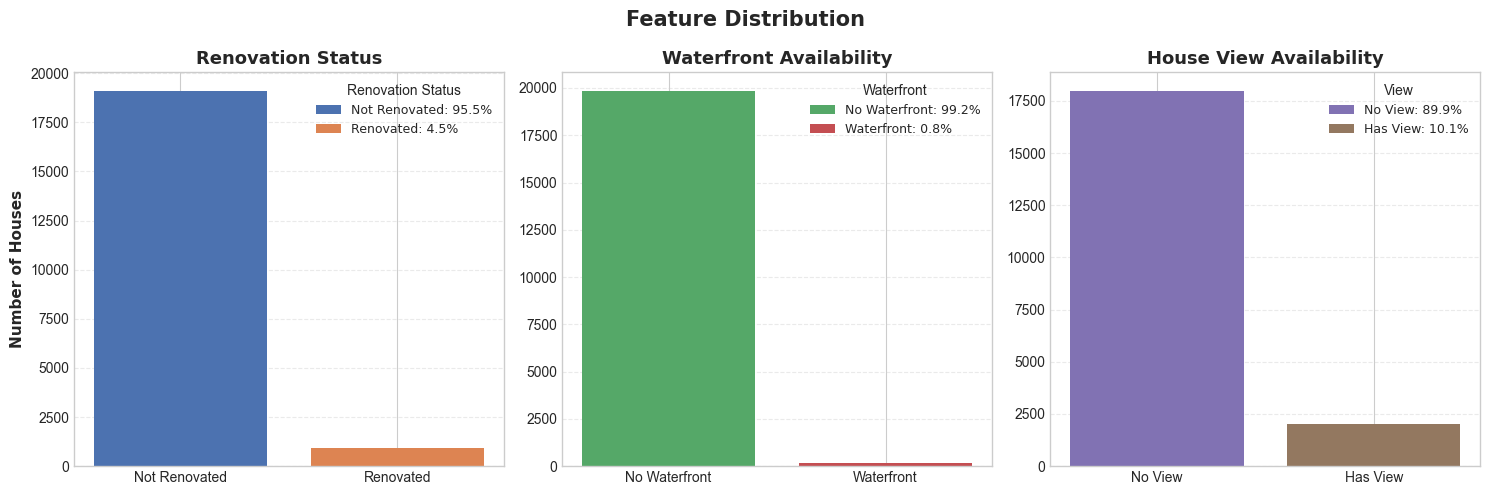

In [ ]:
import matplotlib.pyplot as plt

# Count the number of 0s and 1s in the "renovated", "waterfront", and "view" columns to understand the distribution of these binary features in the dataset and to inform any necessary adjustments or considerations for analysis and visualization.
renovated_counts = df['renovated'].value_counts().sort_index()
waterfront_counts = df['waterfront'].value_counts().sort_index()
view_counts = df['view'].value_counts().sort_index()


def get_percentages(counts):
    total = counts.sum()
    return (counts / total * 100).round(1)


# Using a clean style for the plots to enhance readability and aesthetics.
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Common font settings for labels, titles, and legends to ensure consistency and improve the overall appearance of the plots.
label_font = {"fontsize": 11, "fontweight": "bold", "family": "DejaVu Sans"}
title_font = {"fontsize": 13, "fontweight": "bold", "family": "DejaVu Sans"}
legend_font = {"size": 9, "family": "DejaVu Sans"}

# -------------------
# Renovation Status 
# -------------------
renovated_pct = get_percentages(renovated_counts)

bars = axes[0].bar(
    ['Not Renovated', 'Renovated'],
    renovated_counts,
    color=['#4c72b0', '#dd8452']  #color palette
)

axes[0].legend(
    bars,
    [f"Not Renovated: {renovated_pct[0]}%",
     f"Renovated: {renovated_pct[1]}%"],
    title="Renovation Status",
    prop=legend_font,
    title_fontsize=10
)

axes[0].set_title('Renovation Status', **title_font)
axes[0].set_ylabel('Number of Houses', **label_font)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# -------------------
# Waterfront status
# -------------------
waterfront_pct = get_percentages(waterfront_counts)

bars = axes[1].bar(
    ['No Waterfront', 'Waterfront'],
    waterfront_counts,
    color=['#55a868', '#c44e52']  #color palette
)

axes[1].legend(
    bars,
    [f"No Waterfront: {waterfront_pct[0]}%",
     f"Waterfront: {waterfront_pct[1]}%"],
    title="Waterfront",
    prop=legend_font,
    title_fontsize=10
)

axes[1].set_title('Waterfront Availability', **title_font)
axes[1].tick_params(axis='x', labelsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# -------------------
# View status
# -------------------
view_pct = get_percentages(view_counts)

bars = axes[2].bar(
    ['No View', 'Has View'],
    view_counts,
    color=['#8172b3', '#937860']  # color palette
)

axes[2].legend(
    bars,
    [f"No View: {view_pct[0]}%",
     f"Has View: {view_pct[1]}%"],
    title="View",
    prop=legend_font,
    title_fontsize=10
)

axes[2].set_title('House View Availability', **title_font)
axes[2].tick_params(axis='x', labelsize=10)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

# Layout status
plt.suptitle('Feature Distribution', fontsize=15, fontweight='bold', family='DejaVu Sans')
plt.tight_layout()
plt.savefig("Feature_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()


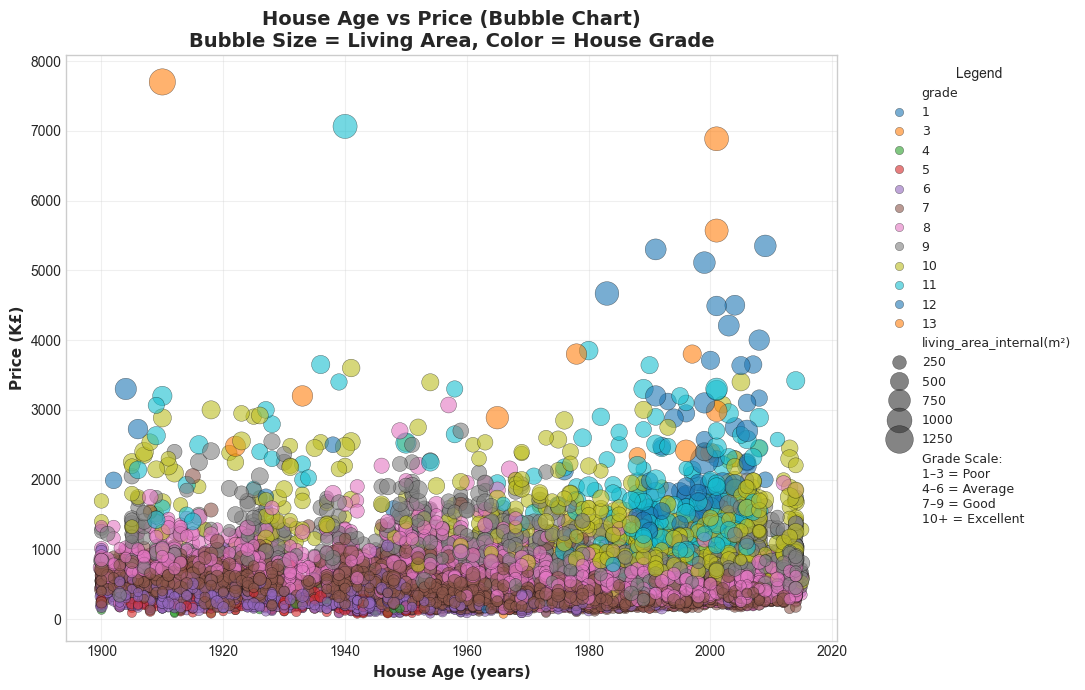

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Global style
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(11, 7))

# Font settings
axis_font = {"fontsize": 11, "fontweight": "bold", "family": "DejaVu Sans"}
title_font = {"fontsize": 14, "fontweight": "bold", "family": "DejaVu Sans"}
legend_font = {"size": 9, "family": "DejaVu Sans"}

# Custom color palette (brighter than default viridis)
palette = sns.color_palette("tab10", n_colors=df['grade'].nunique())

sns.scatterplot(
    x='built',
    y='price(K£)',
    size='living_area_internal(m²)',   # bubble size
    hue='grade',                       # color by grade
    sizes=(30, 400),                   # slightly smaller bubbles
    alpha=0.6,                         # more transparency
    palette=palette,
    edgecolor='black',
    linewidth=0.3,
    data=df
)

plt.title(
    "House Age vs Price (Bubble Chart)\n"
    "Bubble Size = Living Area, Color = House Grade",
    **title_font
)
plt.xlabel("House Age (years)", **axis_font)
plt.ylabel("Price (K£)", **axis_font)

# -------- Custom legend note for grade scale --------
grade_note = Line2D(
    [], [], color='none',
    label=(
        "Grade Scale:\n"
        "1–3 = Poor\n"
        "4–6 = Average\n"
        "7–9 = Good\n"
        "10+ = Excellent"
    )
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(grade_note)

plt.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Legend",
    prop=legend_font,
    title_fontsize=10
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("House_Age_vs_Price_Colorful_Bubble.png", dpi=300, bbox_inches='tight')
plt.show()


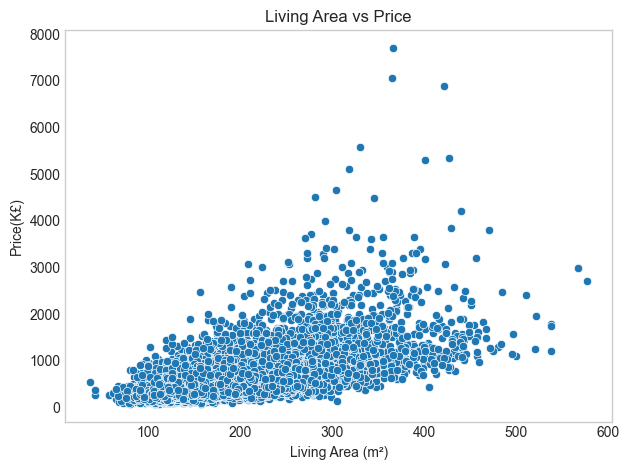

In [ ]:
sns.scatterplot(x='living_area(m²)', y='price(K£)', data=df)
plt.title("Living Area vs Price")
plt.xlabel("Living Area (m²)")
plt.ylabel("Price(K£)")
plt.tight_layout()
plt.savefig("Living Area vs Price Scatter Plot.png", dpi=1000)
plt.grid()
plt.show()


C:\Users\usman\AppData\Local\Temp\ipykernel_22912\221395693.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(
C:\Users\usman\AppData\Local\Temp\ipykernel_22912\221395693.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = ax4.boxplot(


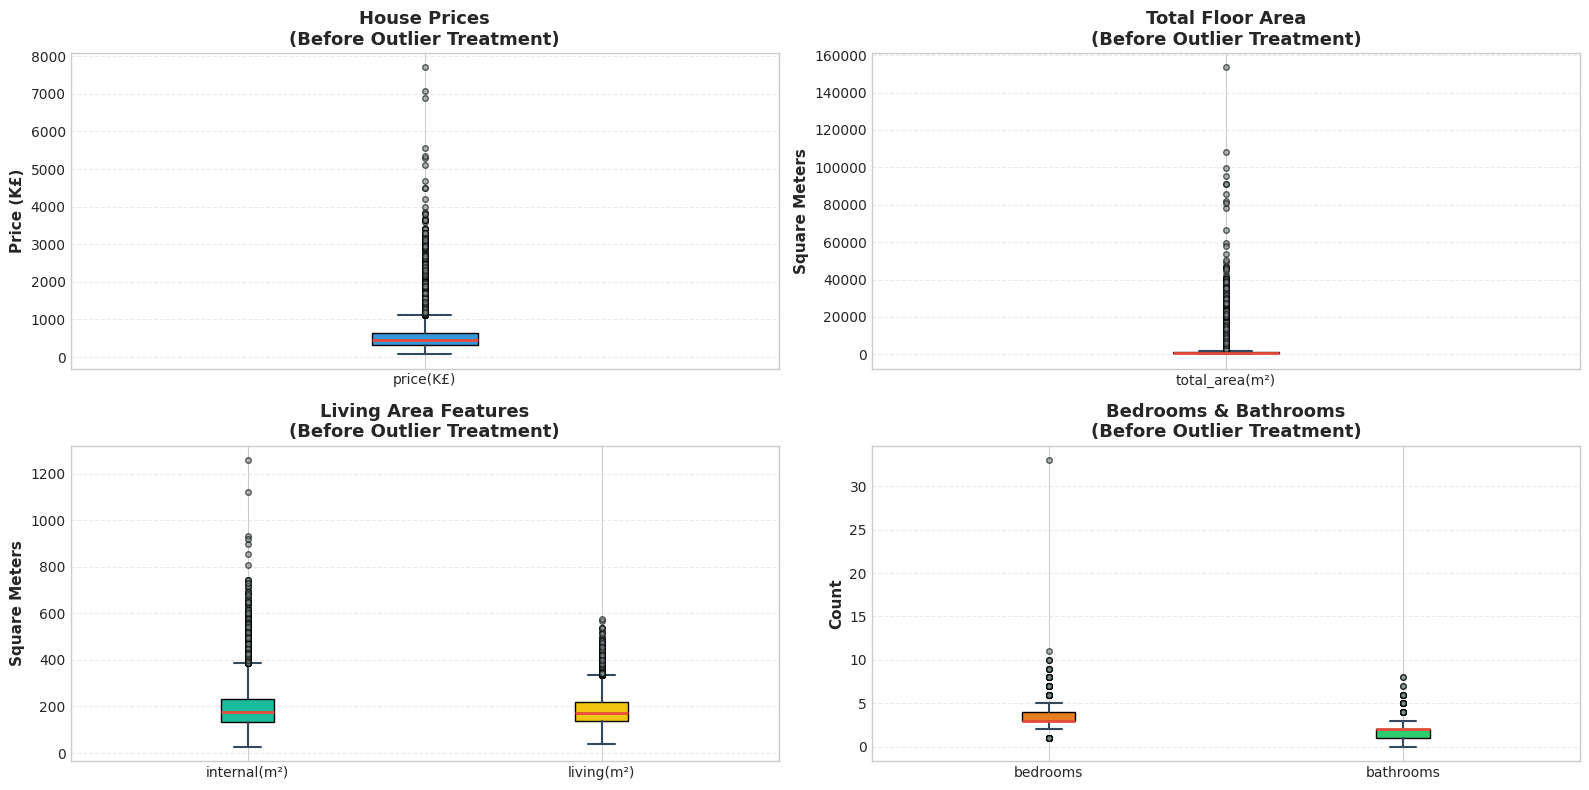

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

box_style = dict(
    patch_artist=True,
    medianprops=dict(color='#e74c3c', linewidth=2),
    whiskerprops=dict(color='#34495e', linewidth=1.5),
    capprops=dict(color='#34495e', linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.6, markerfacecolor='#7f8c8d')
)

title_font = {"fontsize": 13, "fontweight": "bold"}
label_font = {"fontsize": 11, "fontweight": "bold"}

colors_price      = ['#3498db']
colors_total_area = ['#9b59b6']
colors_living     = ['#1abc9c', '#f1c40f']
colors_bed_bath   = ['#e67e22', '#2ecc71']

# 1. Price
ax1 = axes[0, 0]
bp1 = ax1.boxplot(df['price(K£)'], **box_style)
for patch, color in zip(bp1['boxes'], colors_price):
    patch.set_facecolor(color)
ax1.set_xticklabels(['price(K£)'])
ax1.set_title('House Prices\n(Before Outlier Treatment)', **title_font)
ax1.set_ylabel('Price (K£)', **label_font)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# 2. Total Floor Area
ax2 = axes[0, 1]
bp2 = ax2.boxplot(df['total_area(m²)'], **box_style)
for patch, color in zip(bp2['boxes'], colors_total_area):
    patch.set_facecolor(color)
ax2.set_xticklabels(['total_area(m²)'])
ax2.set_title('Total Floor Area\n(Before Outlier Treatment)', **title_font)
ax2.set_ylabel('Square Meters', **label_font)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# 3. Living Area Features
ax3 = axes[1, 0]
bp3 = ax3.boxplot(
    [df['living_area_internal(m²)'], df['living_area(m²)']],
    labels=['internal(m²)', 'living(m²)'],
    **box_style
)
for patch, color in zip(bp3['boxes'], colors_living):
    patch.set_facecolor(color)
ax3.set_title('Living Area Features\n(Before Outlier Treatment)', **title_font)
ax3.set_ylabel('Square Meters', **label_font)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Bedrooms & Bathrooms
ax4 = axes[1, 1]
bp4 = ax4.boxplot(
    [df['bedrooms'], df['bathrooms']],
    labels=['bedrooms', 'bathrooms'],
    **box_style
)
for patch, color in zip(bp4['boxes'], colors_bed_bath):
    patch.set_facecolor(color)
ax4.set_title('Bedrooms & Bathrooms\n(Before Outlier Treatment)', **title_font)
ax4.set_ylabel('Count', **label_font)
ax4.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Before_Outlier_Treatment_Boxplots_2x2.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# OUTLIER REMOVAL USING IQR METHOD (CAPPING)


# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Apply IQR capping to each numeric column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)


C:\Users\usman\AppData\Local\Temp\ipykernel_22912\1632575651.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(
C:\Users\usman\AppData\Local\Temp\ipykernel_22912\1632575651.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = ax4.boxplot(


ValueError: not enough values to unpack (expected 2, got 1)

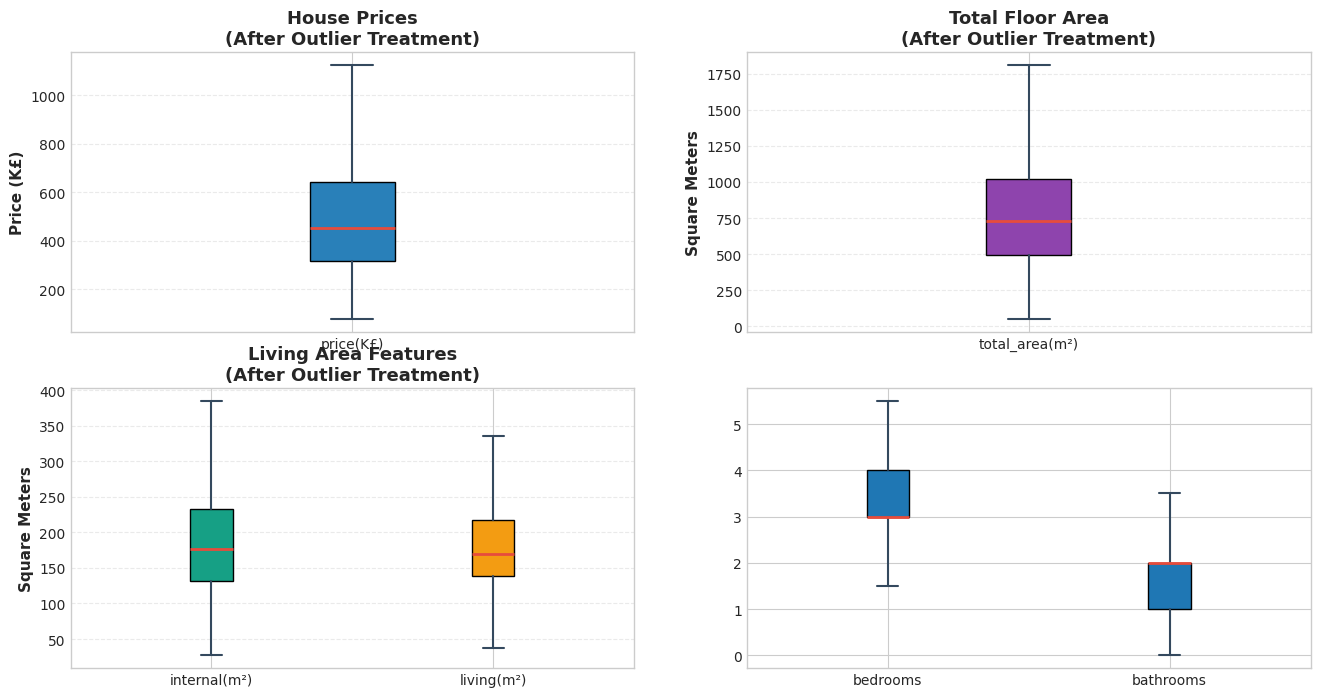

In [ ]:
import matplotlib.pyplot as plt

# Global style and font
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'   # or another installed font

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Common boxplot style
box_style = dict(
    patch_artist=True,
    medianprops=dict(color='#e74c3c', linewidth=2),
    whiskerprops=dict(color='#34495e', linewidth=1.5),
    capprops=dict(color='#34495e', linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.6, markerfacecolor='#7f8c8d')
)

title_font = {"fontsize": 13, "fontweight": "bold"}
label_font = {"fontsize": 11, "fontweight": "bold"}

# Colors per group
colors_price      = ['#2980b9']
colors_total_area = ['#8e44ad']
colors_living     = ['#16a085', '#f39c12']
colors_bed_bath   = ['#d35400', '#27ae60']

# 1. Price (after outlier treatment)
ax1 = axes[0, 0]
bp1 = ax1.boxplot(df['price(K£)'], **box_style)
for patch, color in zip(bp1['boxes'], colors_price):
    patch.set_facecolor(color)
ax1.set_xticklabels(['price(K£)'])
ax1.set_title('House Prices\n(After Outlier Treatment)', **title_font)
ax1.set_ylabel('Price (K£)', **label_font)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# 2. Total Floor Area
ax2 = axes[0, 1]
bp2 = ax2.boxplot(df['total_area(m²)'], **box_style)
for patch, color in zip(bp2['boxes'], colors_total_area):
    patch.set_facecolor(color)
ax2.set_xticklabels(['total_area(m²)'])
ax2.set_title('Total Floor Area\n(After Outlier Treatment)', **title_font)
ax2.set_ylabel('Square Meters', **label_font)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# 3. Living Area Features
ax3 = axes[1, 0]
bp3 = ax3.boxplot(
    [df['living_area_internal(m²)'], df['living_area(m²)']],
    labels=['internal(m²)', 'living(m²)'],
    **box_style
)
for patch, color in zip(bp3['boxes'], colors_living):
    patch.set_facecolor(color)
ax3.set_title('Living Area Features\n(After Outlier Treatment)', **title_font)
ax3.set_ylabel('Square Meters', **label_font)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Bedrooms & Bathrooms
ax4 = axes[1, 1]
bp4 = ax4.boxplot(
    [df['bedrooms'], df['bathrooms']],
    labels=['bedrooms', 'bathrooms'],
    **box_style
)
for patch, color in zip(bp4):
    patch.set_facecolor(color)
ax4.set_title('Bedrooms & Bathrooms\n(After Outlier Treatment)', **title_font)
ax4.set_ylabel('Count', **label_font)       


C:\Users\usman\AppData\Local\Temp\ipykernel_22912\355320617.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


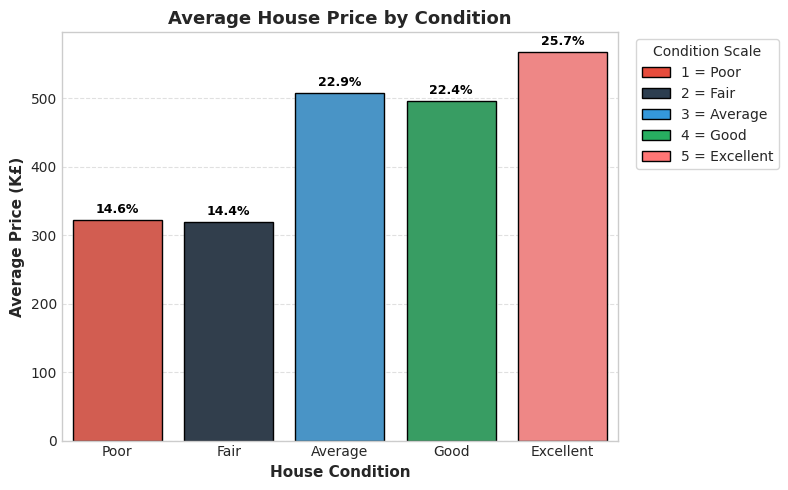

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# Ensure condition is integer
df['condition'] = np.floor(df['condition']).astype(int)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure(figsize=(8, 5))

cond_order = [1, 2, 3, 4, 5]
cond_labels = ['Poor', 'Fair', 'Average', 'Good', 'Excellent']

# Red–black–blue–green theme (+ one lighter red)
palette = ['#e74c3c', '#2c3e50', '#3498db', '#27ae60', '#ff7675']

ax = sns.barplot(
    x='condition',
    y='price(K£)',
    data=df,
    order=cond_order,
    palette=palette,
    errorbar=None,
    capsize=0.05,
    edgecolor='black'
)

plt.ylim(bottom=0)

plt.xlabel('House Condition', fontsize=11, fontweight='bold')
plt.ylabel('Average Price (K£)', fontsize=11, fontweight='bold')
plt.title('Average House Price by Condition', fontsize=13, fontweight='bold')

plt.xticks(ticks=range(len(cond_order)), labels=cond_labels)

# Percentages on top of bars
means = df.groupby('condition')['price(K£)'].mean().reindex(cond_order)
total_mean = means.sum()

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    pct = (means.iloc[i] / total_mean) * 100
    ax.annotate(
        f'{pct:.1f}%',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='black',
        xytext=(0, 3),
        textcoords='offset points'
    )

# Legend using same colors
legend_elements = [
    Patch(facecolor=palette[0], edgecolor='black', label='1 = Poor'),
    Patch(facecolor=palette[1], edgecolor='black', label='2 = Fair'),
    Patch(facecolor=palette[2], edgecolor='black', label='3 = Average'),
    Patch(facecolor=palette[3], edgecolor='black', label='4 = Good'),
    Patch(facecolor=palette[4], edgecolor='black', label='5 = Excellent')
]

plt.legend(
    handles=legend_elements,
    title="Condition Scale",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Price_by_Condition_Bar_with_Percent_RGBG.png", dpi=300, bbox_inches='tight')
plt.show()


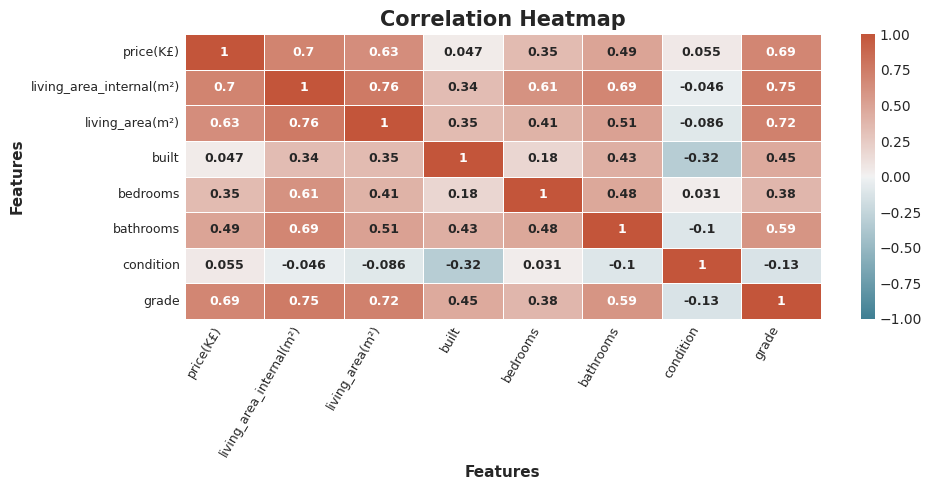

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    'price(K£)',
    'living_area_internal(m²)',
    'living_area(m²)',
    'built',
    'bedrooms',
    'bathrooms',
    'condition',
    'grade'
]

# Global style and font
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'   # or another installed font

plt.figure(figsize=(10, 5))

corr = df[corr_cols].corr()

# Diverging colormap centered at 0 for meaningful colors
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr,
    cmap=cmap,
    annot=True,
    annot_kws={"fontsize": 9, "fontweight": "bold"},  # numbers in cells
    vmin=-1,
    vmax=1,
    center=0,
    square=False,
    linewidths=0.5,
    linecolor='white'
)

plt.title("Correlation Heatmap", fontsize=15, fontweight='bold')
plt.xlabel("Features", fontsize=11, fontweight='bold')
plt.ylabel("Features", fontsize=11, fontweight='bold')

plt.xticks(rotation=60, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("Correlation_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Z-score for numerical columns
z_scores = df[['price(K£)', 'living_area(m²)','living_area_internal(m²)', 'total_area(m²)']].apply(zscore)

# Add to dataframe
df[['price_z', 'living_area_z','sqft_living_z', 'sqft_total_z']] = z_scores

z_scores.head()


,price(K£),living_area(m²),living_area_internal(m²),total_area(m²)
0,-1.145522,-0.976461,-1.040178,-0.668342
1,0.122887,-0.427256,0.651181,-0.354476
2,-1.313653,1.188975,-1.539068,0.189269
3,0.387724,-0.945078,-0.091070,-0.796491
4,0.010532,-0.254649,-0.431775,-0.189263


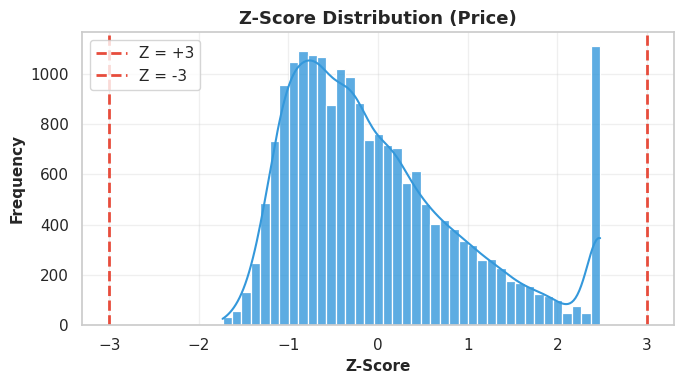

In [ ]:
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

# Z-score calculation
df['price_z'] = zscore(df['price(K£)'])

# Global style and font
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'   # or another installed font

plt.figure(figsize=(7, 4))

sns.histplot(
    df['price_z'],
    bins=40,
    kde=True,
    color='#3498db',
    edgecolor='white',
    alpha=0.8
)

# Z = ±3 reference lines
plt.axvline(3, color='#e74c3c', linestyle='--', linewidth=2, label='Z = +3')
plt.axvline(-3, color='#e74c3c', linestyle='--', linewidth=2, label='Z = -3')

plt.xlabel('Z-Score', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Z-Score Distribution (Price)', fontsize=13, fontweight='bold')

plt.legend(frameon=True)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Z-Score_Test_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# T-score from Z-score
t_scores = 50 + 10 * z_scores

# Add to dataframe
df[['price_t', 'living_area(m²)_t','living_area_internal(m²)_t', 'total_area(m²)_t']] = t_scores
t_scores.head()


,price(K£),living_area(m²),living_area_internal(m²),total_area(m²)
0,38.544784,40.235391,39.598222,43.316578
1,51.228872,45.727440,56.511810,46.455239
2,36.863470,61.889755,34.609322,51.892694
3,53.877242,40.549223,49.089300,42.035089
4,50.105321,47.453512,45.682246,48.107374


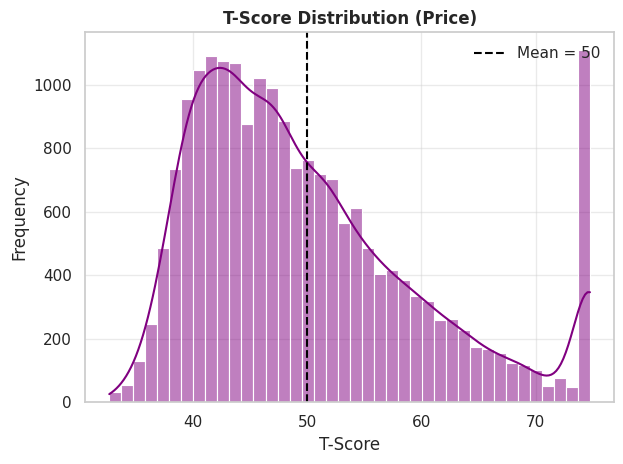

In [ ]:
#T-Score Visualization

sns.histplot(
    df['price_t'],
    kde=True,
    bins=40,
    color='purple'
)

plt.axvline(50, color='black', linestyle='--', label='Mean = 50')
plt.title('T-Score Distribution (Price)', fontsize=12, weight='bold')
plt.xlabel('T-Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("T-Score Visualization.png", dpi=1000)
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(df['floors'], df['grade'])

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 5))


Chi-square statistic: 5595.286
Degrees of freedom: 10
P-value: 0.0


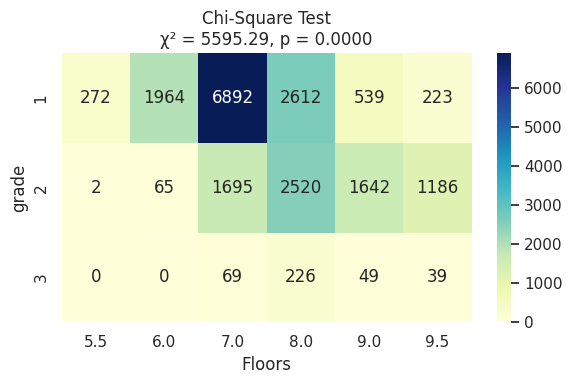

In [ ]:
# Contingency table
contingency = pd.crosstab(df['floors'], df['grade'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Chi-square visualization
plt.figure(figsize=(6,4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Floors')
plt.ylabel('grade')
plt.title(f'Chi-Square Test\nχ² = {chi2:.2f}, p = {p:.4f}')
plt.tight_layout()
plt.savefig("CHi-Square Test Visualization.png", dpi=1000)
plt.show()
